# Terraces Semantic Segmentation - U-Net (3 Approaches)

Comparison of three segmentation architectures on the same aerial terrace dataset, trained and evaluated under identical conditions:

1. **Vanilla U-Net** - trained from scratch (BatchNorm double-conv blocks, BCE+Dice loss).
2. **U-Net + ResNet-34 encoder** - ImageNet-pretrained encoder via `segmentation_models_pytorch`, Focal+Dice loss.
3. **Attention U-Net** - soft attention gates (Oktay et al., 2018), trained from scratch.

Each model is trained on 512x512 GeoTIFF tiles, checkpointed on best validation IoU, and compared on IoU/Dice. The best model is then run on unseen tiles to produce geo-referenced prediction masks.

> **Data note:** the aerial tiles and hand-labelled masks are internship data and are not included in this repository. Set `MAP_DIR`, `MASK_DIR` and `NEW_TILES_DIR` to point at your own dataset before running.

In [5]:
!pip install rasterio segmentation-models-pytorch albumentations tqdm timm torch torchvision

print("All libraries ready")

All libraries ready


In [23]:
# CELL 2 | Imports & Global Configuration
import os
import sys
import random
import warnings
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import rasterio
from rasterio.errors import NotGeoreferencedWarning

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)
warnings.filterwarnings("ignore", category=UserWarning)

MAP_DIR  = Path("Final Dataset/map")       # folder with map_00001.tif …
MASK_DIR = Path("Final Dataset/mask")      # folder with mask_00001.tif …

# Working directories (created automatically)
WORK_DIR  = Path("./terrace_seg")
CKPT_DIR  = WORK_DIR / "checkpoints"
for d in [WORK_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -- Hyper-parameters ----------------------------------------------------------
TARGET_SIZE  = 512          # tiles of any other size will be discarded
N_CHANNELS   = 3            # RGB (first 3 bands are used; alpha dropped)
BATCH_SIZE   = 4            # lower to 2 if GPU OOM; raise to 8 if memory allows
NUM_EPOCHS   = 50           # training epochs per approach (early stopping may cut short)
VAL_SPLIT    = 0.20         # 20 % validation
LR_SCRATCH   = 1e-3         # learning rate for from-scratch models
LR_PRETRAIN  = 1e-4         # learning rate for pretrained encoder
NUM_WORKERS  = 0 if sys.platform == "win32" else min(4, os.cpu_count() or 1)
THRESHOLD    = 0.50         # sigmoid threshold for binary prediction
SEED         = 42

# -- Device --------------------------------------------------------------------
DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print(f"Device    : {DEVICE}")
print(f"Batch     : {BATCH_SIZE}   Epochs: {NUM_EPOCHS}   Workers: {NUM_WORKERS}")
print(f"MAP_DIR   : {MAP_DIR}")
print(f"MASK_DIR  : {MASK_DIR}")


Device    : cuda
Batch     : 4   Epochs: 50   Workers: 4
MAP_DIR   : Final Dataset/map
MASK_DIR  : Final Dataset/mask


In [24]:
# CELL 3 | Filter Tiles — Remove Any Non-512×512 Files

def get_rasterio_size(path: Path):
    """Return (width, height) of a .tif, or (None, None) on error."""
    try:
        with rasterio.open(path) as src:
            return src.width, src.height
    except Exception:
        return None, None


def tile_index(path: Path) -> str:
    """Extract the numeric suffix from a tile name, e.g. 'map_00001' → '00001'."""
    return path.stem.split("_")[-1]


all_map_tiles  = sorted(MAP_DIR.glob("*.tif"))
all_mask_tiles = sorted(MASK_DIR.glob("*.tif"))
print(f"Found  {len(all_map_tiles)} map tiles  |  {len(all_mask_tiles)} mask tiles")

map_dict  = {tile_index(p): p for p in all_map_tiles}
mask_dict = {tile_index(p): p for p in all_mask_tiles}
common    = sorted(set(map_dict) & set(mask_dict))
print(f"Paired (both folders): {len(common)}")

valid_pairs: list[tuple[Path, Path]] = []
removed_ids: list[str] = []

for tid in tqdm(common, desc="Checking tile sizes"):
    mp, mk = map_dict[tid], mask_dict[tid]
    wm, hm = get_rasterio_size(mp)
    wk, hk = get_rasterio_size(mk)
    if (wm, hm) == (TARGET_SIZE, TARGET_SIZE) and (wk, hk) == (TARGET_SIZE, TARGET_SIZE):
        valid_pairs.append((mp, mk))
    else:
        removed_ids.append(tid)

print(f"\nValid {TARGET_SIZE}×{TARGET_SIZE} pairs : {len(valid_pairs)}")
print(f"Removed (wrong size)         : {len(removed_ids)}")
if removed_ids:
    preview = removed_ids[:10]
    print(f"  First removed IDs : {preview}{'…' if len(removed_ids) > 10 else ''}")

Found  985 map tiles  |  985 mask tiles
Paired (both folders): 985


Checking tile sizes: 100%|██████████| 985/985 [00:03<00:00, 306.33it/s]


Valid 512×512 pairs : 984
Removed (wrong size)         : 1
  First removed IDs : ['00784']


In [25]:
# CELL 4 | Train / Val Split  (80 / 20, path-based — no file copy)

random.shuffle(valid_pairs)
split_idx   = int(len(valid_pairs) * (1.0 - VAL_SPLIT))
train_pairs = valid_pairs[:split_idx]
val_pairs   = valid_pairs[split_idx:]

train_map_paths  = [p[0] for p in train_pairs]
train_mask_paths = [p[1] for p in train_pairs]
val_map_paths    = [p[0] for p in val_pairs]
val_mask_paths   = [p[1] for p in val_pairs]

print(f"Train : {len(train_pairs)} tile pairs")
print(f"Val   : {len(val_pairs)}  tile pairs")

Train : 787 tile pairs
Val   : 197  tile pairs


In [26]:
# CELL 5 | Dataset Class & Per-Approach Augmentation Pipelines

class TerraceDataset(Dataset):
    """
    Reads .tif map tiles with rasterio.
    • Map  → float32 (H,W,3) normalised to [0,1]
    • Mask → float32 (H,W)   binary {0,1}
    """

    def __init__(self, map_paths, mask_paths, transform=None):
        assert len(map_paths) == len(mask_paths), "Mismatched map / mask counts"
        self.map_paths   = list(map_paths)
        self.mask_paths  = list(mask_paths)
        self.transform   = transform

    def __len__(self):
        return len(self.map_paths)

    @staticmethod
    def _read_image(path: Path) -> np.ndarray:
        """Return (H, W, 3) float32 in [0, 1]."""
        with rasterio.open(path) as src:
            data = src.read()                             # (C, H, W)
        # Keep only first 3 bands; pad to 3 if fewer
        if data.shape[0] >= 3:
            data = data[:3]
        else:
            pad = np.zeros((3 - data.shape[0], *data.shape[1:]), dtype=data.dtype)
            data = np.concatenate([data, pad], axis=0)

        img = np.moveaxis(data, 0, -1).astype(np.float32)  # (H, W, 3)

        # Normalise uint8 → [0,1] or clip float tiles
        if img.dtype == np.float32 and img.max() > 1.0:
            img = img / 255.0
        img = np.clip(img, 0.0, 1.0)
        return img

    @staticmethod
    def _read_mask(path: Path) -> np.ndarray:
        """Return (H, W) float32 binary {0,1}."""
        with rasterio.open(path) as src:
            mask = src.read(1).astype(np.float32)
        return (mask > 0).astype(np.float32)

    def __getitem__(self, idx):
        image = self._read_image(self.map_paths[idx])    # (H, W, 3)
        mask  = self._read_mask(self.mask_paths[idx])    # (H, W)

        if self.transform:
            out   = self.transform(image=image, mask=mask)
            image = out["image"]                         # tensor (3, H, W)
            mask  = out["mask"]                          # tensor (H, W)
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1))
            mask  = torch.from_numpy(mask)

        return image, mask.unsqueeze(0).float()          # (1, H, W)


# -- ImageNet statistics (used by the pretrained encoder) ---------------------
_IN_MEAN = [0.485, 0.456, 0.406]
_IN_STD  = [0.229, 0.224, 0.225]


def _aug_train_v1():
    """Approach 1 — standard geometric + colour augmentations."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
        ToTensorV2(),
    ])

def _aug_val_v1():
    return A.Compose([ToTensorV2()])


def _aug_train_v2():
    """Approach 2 — extra distortions + ImageNet normalisation."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(0.25, 0.25, p=0.4),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.25),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
        A.Normalize(mean=_IN_MEAN, std=_IN_STD),
        ToTensorV2(),
    ])

def _aug_val_v2():
    return A.Compose([
        A.Normalize(mean=_IN_MEAN, std=_IN_STD),
        ToTensorV2(),
    ])


def _aug_train_v3():
    """Approach 3 — elastic deformation for attention U-Net."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ElasticTransform(alpha=60, sigma=12, p=0.25),
        A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
        ToTensorV2(),
    ])

def _aug_val_v3():
    return A.Compose([ToTensorV2()])


print("TerraceDataset and augmentation pipelines defined")

TerraceDataset and augmentation pipelines defined


In [27]:
# CELL 6 | Model Architectures  (3 approaches)
# -----------------------------------------------------------------------------

# ============================================================================
# APPROACH 1 — Vanilla U-Net (from scratch)
#   • BatchNorm + ReLU double-conv blocks
#   • Dropout in bottleneck for regularisation
#   • ConvTranspose2d upsampling
# ============================================================================

class _DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VanillaUNet(nn.Module):
    """Standard U-Net — Ronneberger et al. (2015) with BatchNorm."""

    FEATURES = (64, 128, 256, 512)

    def __init__(self, in_channels: int = 3, out_channels: int = 1):
        super().__init__()
        feats = self.FEATURES
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        self.enc = nn.ModuleList()
        ch = in_channels
        for f in feats:
            self.enc.append(_DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = _DoubleConv(feats[-1], feats[-1] * 2, dropout=0.3)

        # Decoder
        self.dec_up   = nn.ModuleList()
        self.dec_conv = nn.ModuleList()
        ch = feats[-1] * 2
        for f in reversed(feats):
            self.dec_up.append(nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2))
            self.dec_conv.append(_DoubleConv(f * 2, f))
            ch = f

        self.head = nn.Conv2d(feats[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc in self.enc:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for up, conv, skip in zip(self.dec_up, self.dec_conv, skips[::-1]):
            x = up(x)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
            x = conv(torch.cat([skip, x], dim=1))

        return self.head(x)


# ============================================================================
# APPROACH 2 — U-Net with pretrained ResNet-34 encoder  (via smp)
#   • ImageNet-initialised encoder → much faster convergence
#   • Decoder mirrors the vanilla U-Net structure
#   • Best for RGB input (3-channel)
# ============================================================================

def build_pretrained_unet(in_channels: int = 3, out_channels: int = 1):
    return smp.Unet(
        encoder_name    = "resnet34",
        encoder_weights = "imagenet",
        in_channels     = in_channels,
        classes         = out_channels,
        activation      = None,          # raw logits — sigmoid applied in loss
    )


# ============================================================================
# APPROACH 3 — Attention U-Net  (from scratch)
#   • Soft attention gates (Oktay et al., 2018) suppress irrelevant regions
#   • Better precision on small / sparse terrace structures
# ============================================================================

class _AttentionGate(nn.Module):
    def __init__(self, F_g: int, F_l: int, F_int: int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=False), nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode="bilinear", align_corners=False)
        alpha = self.psi(self.relu(self.W_g(g) + self.W_x(x)))
        return x * alpha


class AttentionUNet(nn.Module):
    """U-Net with soft attention gates — Oktay et al. (2018)."""

    FEATURES = (64, 128, 256, 512)

    def __init__(self, in_channels: int = 3, out_channels: int = 1):
        super().__init__()
        feats = self.FEATURES
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        self.enc = nn.ModuleList()
        ch = in_channels
        for f in feats:
            self.enc.append(_DoubleConv(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = _DoubleConv(feats[-1], feats[-1] * 2, dropout=0.3)

        # Decoder
        self.dec_up   = nn.ModuleList()
        self.dec_att  = nn.ModuleList()
        self.dec_conv = nn.ModuleList()
        ch = feats[-1] * 2
        for f in reversed(feats):
            self.dec_up.append(nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2))
            self.dec_att.append(_AttentionGate(F_g=f, F_l=f, F_int=f // 2))
            self.dec_conv.append(_DoubleConv(f * 2, f))
            ch = f

        self.head = nn.Conv2d(feats[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc in self.enc:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for up, att, conv, skip in zip(self.dec_up, self.dec_att, self.dec_conv, skips[::-1]):
            x    = up(x)
            skip = att(g=x, x=skip)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
            x = conv(torch.cat([skip, x], dim=1))

        return self.head(x)


def count_params(model: nn.Module) -> str:
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return f"{n/1e6:.2f}M"


print("- All 3 architectures defined")
for name, cls in [("Vanilla U-Net", VanillaUNet),
                  ("Attention U-Net", AttentionUNet)]:
    m = cls(in_channels=N_CHANNELS)
    print(f"  {name:<22} → {count_params(m)} trainable params")
m2 = build_pretrained_unet(in_channels=3)
print(f"  {'U-Net + ResNet34':<22} → {count_params(m2)} trainable params")
del m, m2


✓ All 3 architectures defined
  Vanilla U-Net          → 31.04M trainable params
  Attention U-Net        → 31.39M trainable params
  U-Net + ResNet34       → 24.44M trainable params


In [28]:
# CELL 7 | Loss Functions & Metrics

class DiceLoss(nn.Module):
    """Soft Dice loss computed over each sample in the batch."""

    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs   = torch.sigmoid(logits)
        b       = probs.size(0)
        probs   = probs.view(b, -1)
        targets = targets.view(b, -1)
        inter   = (probs * targets).sum(1)
        union   = probs.sum(1) + targets.sum(1)
        dice    = (2.0 * inter + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    """
    BCE + Dice — Approaches 1 & 3.
    Combines pixel-level (BCE) and region-level (Dice) supervision.
    Works well even with moderate class imbalance.
    """

    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce       = nn.BCEWithLogitsLoss()
        self.dice      = DiceLoss()
        self.bce_w     = bce_weight

    def forward(self, logits, targets):
        return self.bce_w * self.bce(logits, targets) + (1.0 - self.bce_w) * self.dice(logits, targets)


class FocalDiceLoss(nn.Module):
    """
    Focal + Dice — Approach 2.
    Focal loss down-weights easy negatives → focuses on hard terrace pixels.
    Combined with Dice for region-level accuracy.
    """

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, dice_weight: float = 0.5):
        super().__init__()
        self.alpha      = alpha
        self.gamma      = gamma
        self.dice_w     = dice_weight
        self.dice       = DiceLoss()

    def forward(self, logits, targets):
        bce    = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt     = torch.exp(-bce)
        focal  = self.alpha * (1.0 - pt) ** self.gamma * bce
        return (1.0 - self.dice_w) * focal.mean() + self.dice_w * self.dice(logits, targets)


@torch.no_grad()
def compute_metrics(logits: torch.Tensor, targets: torch.Tensor,
                    threshold: float = THRESHOLD) -> dict:
    """Batch-level binary Dice & IoU (Jaccard)."""
    preds = (torch.sigmoid(logits) > threshold).float()
    tp = (preds * targets).sum()
    fp = (preds * (1.0 - targets)).sum()
    fn = ((1.0 - preds) * targets).sum()
    eps = 1e-7
    dice = (2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)
    iou  = (tp + eps) / (tp + fp + fn + eps)
    return {"dice": dice.item(), "iou": iou.item()}


print("  Loss functions & metrics defined")
print("  Approach 1 & 3 → BCEDiceLoss  (BCE 50 % + Dice 50 %)")
print("  Approach 2     → FocalDiceLoss (Focal 50 % + Dice 50 %)")


  Loss functions & metrics defined
  Approach 1 & 3 → BCEDiceLoss  (BCE 50 % + Dice 50 %)
  Approach 2     → FocalDiceLoss (Focal 50 % + Dice 50 %)


In [29]:
# CELL 8 | Training & Validation Loop

def _get_autocast(device: str):
    """Return an autocast context manager (CUDA only; no-op elsewhere)."""
    if device == "cuda":
        try:
            return torch.amp.autocast(device_type="cuda")
        except AttributeError:
            return torch.cuda.amp.autocast()
    return nullcontext()


def _get_scaler(device: str):
    if device != "cuda":
        return None
    return torch.cuda.amp.GradScaler()


def train_one_epoch(model, loader, optimizer, criterion, device,
                    scaler=None, batch_scheduler=None):
    model.train()
    tot_loss = 0.0
    tot_dice = 0.0
    tot_iou  = 0.0

    pbar = tqdm(loader, desc="  train", leave=False, unit="batch")
    for images, masks in pbar:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with _get_autocast(device):
            logits = model(images)
            loss   = criterion(logits, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        if batch_scheduler is not None:
            batch_scheduler.step()

        m = compute_metrics(logits.detach(), masks)
        tot_loss += loss.item()
        tot_dice += m["dice"]
        tot_iou  += m["iou"]
        pbar.set_postfix(loss=f"{loss.item():.4f}", iou=f"{m['iou']:.4f}")

    n = len(loader)
    return tot_loss / n, {"dice": tot_dice / n, "iou": tot_iou / n}


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    tot_loss = 0.0
    tot_dice = 0.0
    tot_iou  = 0.0

    for images, masks in tqdm(loader, desc="  val  ", leave=False, unit="batch"):
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        with _get_autocast(device):
            logits = model(images)
            loss   = criterion(logits, masks)
        m = compute_metrics(logits, masks)
        tot_loss += loss.item()
        tot_dice += m["dice"]
        tot_iou  += m["iou"]

    n = len(loader)
    return tot_loss / n, {"dice": tot_dice / n, "iou": tot_iou / n}


def run_training(
    model, train_loader, val_loader,
    optimizer, criterion,
    n_epochs: int, device: str, ckpt_path: Path,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience: int = 12,
):
    """
    Full training loop.
    • Saves the best checkpoint by Val IoU.
    • Early-stops after `patience` epochs without improvement.
    Returns (history_dict, best_val_iou).
    """
    scaler = _get_scaler(device)
    history = {k: [] for k in ("train_loss", "val_loss",
                                "train_dice", "val_dice",
                                "train_iou",  "val_iou")}
    best_iou  = -1.0
    no_improv = 0

    for epoch in range(1, n_epochs + 1):
        print(f"Epoch {epoch:3d}/{n_epochs}")

        tr_loss, tr_m = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            scaler=scaler, batch_scheduler=batch_scheduler
        )
        vl_loss, vl_m = validate_one_epoch(model, val_loader, criterion, device)

        # Step epoch-level scheduler
        if epoch_scheduler is not None:
            if isinstance(epoch_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                epoch_scheduler.step(vl_loss)
            else:
                epoch_scheduler.step()

        # Log
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_dice"].append(tr_m["dice"])
        history["val_dice"].append(vl_m["dice"])
        history["train_iou"].append(tr_m["iou"])
        history["val_iou"].append(vl_m["iou"])

        print(f"  Train → loss: {tr_loss:.4f}  Dice: {tr_m['dice']:.4f}  IoU: {tr_m['iou']:.4f}")
        print(f"  Val   → loss: {vl_loss:.4f}  Dice: {vl_m['dice']:.4f}  IoU: {vl_m['iou']:.4f}")

        # Checkpoint
        if vl_m["iou"] > best_iou:
            best_iou  = vl_m["iou"]
            no_improv = 0
            torch.save(
                {"epoch": epoch, "model_state": model.state_dict(), "best_iou": best_iou},
                ckpt_path
            )
            print(f"  - New best  →  checkpoint saved  (IoU={best_iou:.4f})")
        else:
            no_improv += 1
            if no_improv >= patience:
                print(f"  Early stop at epoch {epoch} (no improvement for {patience} epochs)")
                break
        print()

    return history, best_iou


print(" Training loop defined")

 Training loop defined


In [18]:
# CELL 9 | Train All 3 Approaches  (this cell takes the most time)

#    Runtime estimate on a single GPU:
#    • Approach 1 (Vanilla U-Net)    ~  1–2 h for 50 epochs on ~780 tiles
#    • Approach 2 (ResNet34 encoder) ~  1–2 h (faster convergence, same clock time)
#    • Approach 3 (Attention U-Net)  ~  1.5–2.5 h
# -----------------------------------------------------------------------------

# --- Shared DataLoader factory -----------------------------------------------

def make_loaders(train_aug, val_aug, batch_size=BATCH_SIZE):
    ds_tr = TerraceDataset(train_map_paths, train_mask_paths, transform=train_aug)
    ds_vl = TerraceDataset(val_map_paths,   val_mask_paths,   transform=val_aug)
    dl_tr = DataLoader(ds_tr, batch_size, shuffle=True,  num_workers=NUM_WORKERS,
                       pin_memory=(DEVICE == "cuda"), drop_last=True)
    dl_vl = DataLoader(ds_vl, batch_size, shuffle=False, num_workers=NUM_WORKERS,
                       pin_memory=(DEVICE == "cuda"))
    return dl_tr, dl_vl


# ============================================================================
# > APPROACH 1 — Vanilla U-Net | BCE+Dice | Adam | ReduceLROnPlateau
# ============================================================================
print("=" * 64)
print("APPROACH 1  —  Vanilla U-Net")
print("=" * 64)

dl_tr1, dl_vl1 = make_loaders(_aug_train_v1(), _aug_val_v1())

model1  = VanillaUNet(in_channels=N_CHANNELS, out_channels=1).to(DEVICE)
opt1    = torch.optim.Adam(model1.parameters(), lr=LR_SCRATCH, weight_decay=1e-5)
crit1   = BCEDiceLoss(bce_weight=0.5)
sched1  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt1, mode="min", patience=5, factor=0.5, min_lr=1e-6, verbose=False
)

hist1, iou1 = run_training(
    model1, dl_tr1, dl_vl1, opt1, crit1, NUM_EPOCHS, DEVICE,
    CKPT_DIR / "approach1_best.pth",
    epoch_scheduler=sched1, patience=12,
)
print(f"\n{'-'*40}")
print(f"Approach 1  Best Val IoU = {iou1:.4f}")
print(f"{'-'*40}\n")


# ============================================================================
# > APPROACH 2 — U-Net + ResNet34 | FocalDice | AdamW | CosineAnnealing
# ============================================================================
print("=" * 64)
print("APPROACH 2  —  U-Net + ResNet34 (ImageNet pre-trained)")
print("=" * 64)

dl_tr2, dl_vl2 = make_loaders(_aug_train_v2(), _aug_val_v2())

model2  = build_pretrained_unet(in_channels=3, out_channels=1).to(DEVICE)
opt2    = torch.optim.AdamW(model2.parameters(), lr=LR_PRETRAIN, weight_decay=1e-4)
crit2   = FocalDiceLoss(alpha=0.25, gamma=2.0, dice_weight=0.5)
sched2  = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt2, T_max=NUM_EPOCHS, eta_min=1e-7
)

hist2, iou2 = run_training(
    model2, dl_tr2, dl_vl2, opt2, crit2, NUM_EPOCHS, DEVICE,
    CKPT_DIR / "approach2_best.pth",
    epoch_scheduler=sched2, patience=12,
)
print(f"\n{'-'*40}")
print(f"Approach 2  Best Val IoU = {iou2:.4f}")
print(f"{'-'*40}\n")


# ============================================================================
# > APPROACH 3 — Attention U-Net | BCE+Dice | Adam | CosineWarmRestarts
# ============================================================================
print("=" * 64)
print("APPROACH 3  —  Attention U-Net")
print("=" * 64)

dl_tr3, dl_vl3 = make_loaders(_aug_train_v3(), _aug_val_v3())

model3  = AttentionUNet(in_channels=N_CHANNELS, out_channels=1).to(DEVICE)
opt3    = torch.optim.Adam(model3.parameters(), lr=LR_SCRATCH, weight_decay=1e-5)
crit3   = BCEDiceLoss(bce_weight=0.4)   # slightly more Dice weight
sched3  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt3, T_0=10, T_mult=2, eta_min=1e-7
)

hist3, iou3 = run_training(
    model3, dl_tr3, dl_vl3, opt3, crit3, NUM_EPOCHS, DEVICE,
    CKPT_DIR / "approach3_best.pth",
    epoch_scheduler=sched3, patience=12,
)
print(f"\n{'-'*40}")
print(f"Approach 3  Best Val IoU = {iou3:.4f}")
print(f"{'-'*40}\n")


APPROACH 1  —  Vanilla U-Net
Epoch   1/50


  Train → loss: 0.6037  Dice: 0.1698  IoU: 0.1011
  Val   → loss: 0.5540  Dice: 0.2853  IoU: 0.1872
  ✓ New best  →  checkpoint saved  (IoU=0.1872)

Epoch   2/50


  Train → loss: 0.5614  Dice: 0.2686  IoU: 0.1710
  Val   → loss: 0.5506  Dice: 0.2435  IoU: 0.1626

Epoch   3/50


  Train → loss: 0.5562  Dice: 0.2793  IoU: 0.1797
  Val   → loss: 0.5650  Dice: 0.1549  IoU: 0.1002

Epoch   4/50


  Train → loss: 0.5542  Dice: 0.2918  IoU: 0.1875
  Val   → loss: 0.5623  Dice: 0.2425  IoU: 0.1801

Epoch   5/50


...

  Train → loss: 0.5964  Dice: 0.3485  IoU: 0.2329
  Val   → loss: 0.5866  Dice: 0.3244  IoU: 0.2128

Epoch  18/50


  Train → loss: 0.5914  Dice: 0.3515  IoU: 0.2359
  Val   → loss: 0.5965  Dice: 0.3221  IoU: 0.2132

Epoch  19/50


  Train → loss: 0.5831  Dice: 0.3727  IoU: 0.2508
  Val   → loss: 0.5836  Dice: 0.3369  IoU: 0.2261

Epoch  20/50


  Train → loss: 0.5846  Dice: 0.3793  IoU: 0.2578
  Val   → loss: 0.5931  Dice: 0.3213  IoU: 0.2095

Epoch  21/50


  Train → loss: 0.5781  Dice: 0.3786  IoU: 0.2561
  Val   → loss: 0.6176  Dice: 0.3258  IoU: 0.2160
  Early stop at epoch 21 (no improvement for 12 epochs)

────────────────────────────────────────
Approach 3  Best Val IoU = 0.2540
────────────────────────────────────────



In [30]:
# CELL 9 ALTERNATIVE
# DONT TRAIN AGAIN, load pretrained checkpoints from the disk

CKPT_DIR = WORK_DIR / "checkpoints"

def _load_history(ckpt_path):
    """Load best_iou from a saved checkpoint; return (placeholder_history, iou)."""
    if not ckpt_path.exists():
        print(f"  Warning: Missing: {ckpt_path}")
        return None, 0.0
    ck = torch.load(ckpt_path, map_location="cpu")
    iou = float(ck.get("best_iou", 0.0))
    # Placeholder history (real training curves are only available after Cell 9)
    placeholder = {k: [iou] for k in
                   ("train_loss", "val_loss",
                    "train_dice", "val_dice",
                    "train_iou",  "val_iou")}
    return placeholder, iou


hist1, iou1 = _load_history(CKPT_DIR / "approach1_best.pth")
hist2, iou2 = _load_history(CKPT_DIR / "approach2_best.pth")
hist3, iou3 = _load_history(CKPT_DIR / "approach3_best.pth")

print("Loaded checkpoints from disk:")
print(f"  Approach 1 (Vanilla U-Net)    : IoU = {iou1:.4f}")
print(f"  Approach 2 (U-Net + ResNet34) : IoU = {iou2:.4f}")
print(f"  Approach 3 (Attention U-Net)  : IoU = {iou3:.4f}")

Loaded checkpoints from disk:
  Approach 1 (Vanilla U-Net)    : IoU = 0.3250
  Approach 2 (U-Net + ResNet34) : IoU = 0.6553
  Approach 3 (Attention U-Net)  : IoU = 0.2540



════════════════════════════════════════════════════
Approach                 Best Val IoU  Best Val Dice
────────────────────────────────────────────────────
Vanilla U-Net                  0.3250         0.3250
U-Net + ResNet34               0.6553         0.6553
Attention U-Net                0.2540         0.2540
════════════════════════════════════════════════════

🏆  Winner : U-Net + ResNet34  (Val IoU = 0.6553)


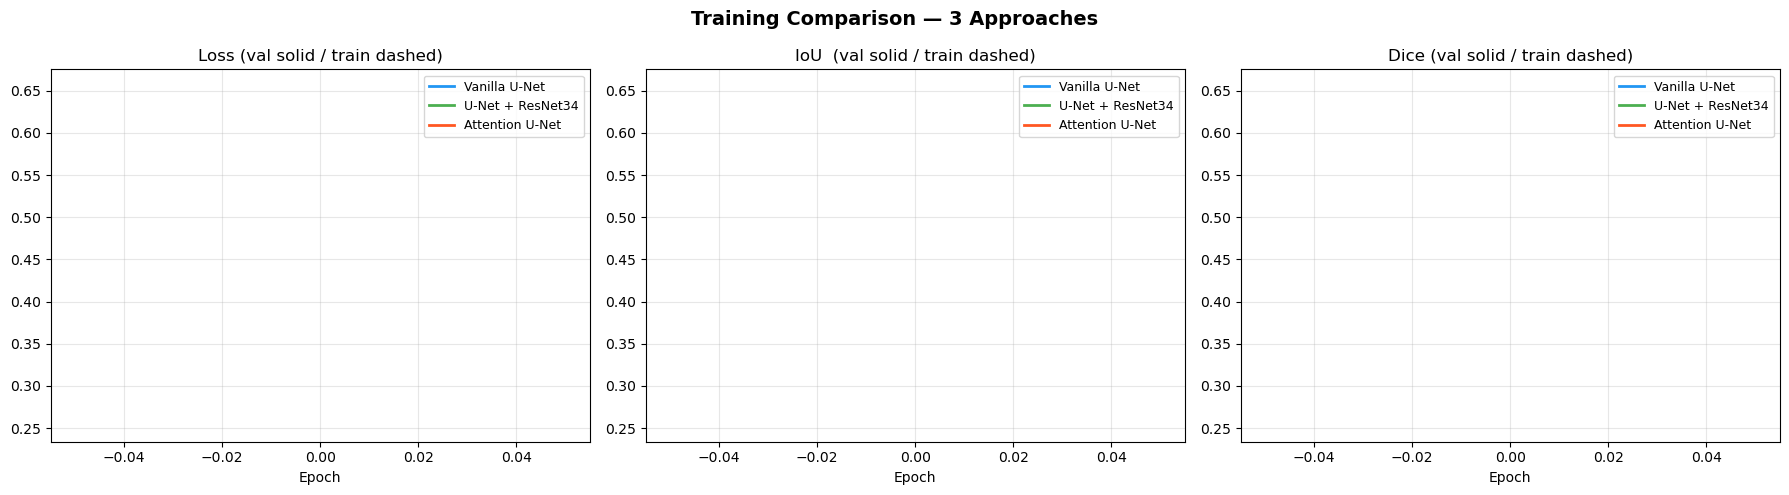

✓ Saved → terrace_seg/training_curves.png


In [31]:
# CELL 10 | Compare Results & Plot Training Curves

RESULTS = {
    "Vanilla U-Net": {
        "iou": iou1, "history": hist1,
        "ckpt": CKPT_DIR / "approach1_best.pth",
        "model_cls": "vanilla",
    },
    "U-Net + ResNet34": {
        "iou": iou2, "history": hist2,
        "ckpt": CKPT_DIR / "approach2_best.pth",
        "model_cls": "pretrained",
    },
    "Attention U-Net": {
        "iou": iou3, "history": hist3,
        "ckpt": CKPT_DIR / "approach3_best.pth",
        "model_cls": "attention",
    },
}

# -- Comparison table ----------------------------------------------------------
print("\n" + "=" * 52)
print(f"{'Approach':<24} {'Best Val IoU':>12}  {'Best Val Dice':>13}")
print("-" * 52)
for name, r in RESULTS.items():
    h    = r["history"]
    best_ep = int(np.argmax(h["val_iou"]))
    dice_at_best = h["val_dice"][best_ep]
    print(f"{name:<24} {r['iou']:>12.4f}  {dice_at_best:>13.4f}")
print("=" * 52)

BEST_NAME = max(RESULTS, key=lambda k: RESULTS[k]["iou"])
print(f"\nWinner:  Winner : {BEST_NAME}  (Val IoU = {RESULTS[BEST_NAME]['iou']:.4f})")

# -- Training curves -----------------------------------------------------------
colors = {"Vanilla U-Net": "#2196F3", "U-Net + ResNet34": "#4CAF50", "Attention U-Net": "#FF5722"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, r in RESULTS.items():
    h, c = r["history"], colors[name]
    axes[0].plot(h["val_loss"],  label=name, color=c, lw=2)
    axes[0].plot(h["train_loss"],        color=c, lw=1, ls="--", alpha=0.45)
    axes[1].plot(h["val_iou"],   label=name, color=c, lw=2)
    axes[1].plot(h["train_iou"],         color=c, lw=1, ls="--", alpha=0.45)
    axes[2].plot(h["val_dice"],  label=name, color=c, lw=2)
    axes[2].plot(h["train_dice"],        color=c, lw=1, ls="--", alpha=0.45)

titles = ["Loss (val solid / train dashed)", "IoU  (val solid / train dashed)",
          "Dice (val solid / train dashed)"]
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Training Comparison — 3 Approaches", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(WORK_DIR / "training_curves.png", dpi=150)
plt.show()
print(f"- Saved → {WORK_DIR / 'training_curves.png'}")


✓ Loaded  'U-Net + ResNet34'
  Checkpoint: epoch 44  |  Val IoU = 0.6553


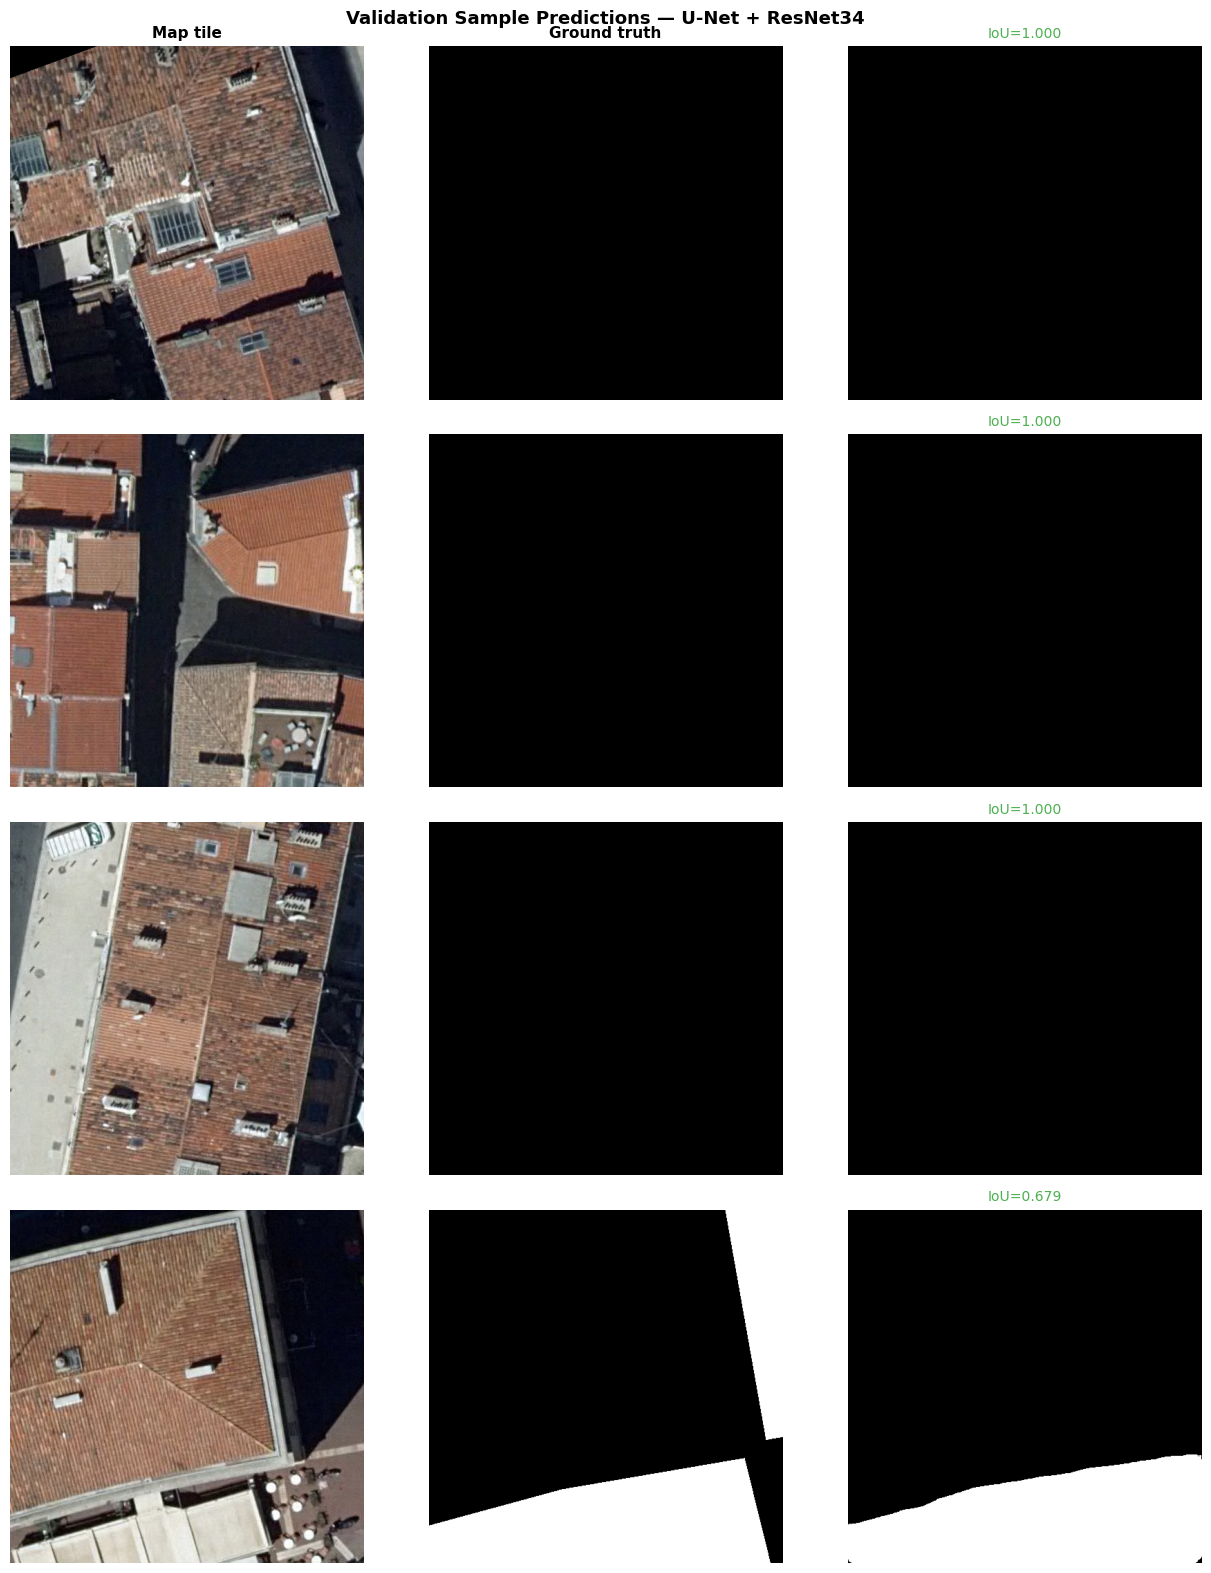

✓ Saved → terrace_seg/sample_predictions.png


In [32]:
# CELL 11 | Load Best Model & Visualise Validation Predictions

def _rebuild_model(model_cls: str) -> nn.Module:
    if model_cls == "vanilla":
        return VanillaUNet(in_channels=N_CHANNELS, out_channels=1)
    elif model_cls == "pretrained":
        return build_pretrained_unet(in_channels=3, out_channels=1)
    else:
        return AttentionUNet(in_channels=N_CHANNELS, out_channels=1)


def _val_transform(model_cls: str):
    if model_cls == "pretrained":
        return _aug_val_v2()
    return _aug_val_v1()   # v1 and v3 val transforms are identical


# Load winner
best_info   = RESULTS[BEST_NAME]
best_model  = _rebuild_model(best_info["model_cls"]).to(DEVICE)
best_ckpt   = torch.load(best_info["ckpt"], map_location=DEVICE)
best_model.load_state_dict(best_ckpt["model_state"])
best_model.eval()
BEST_TRANSFORM = _val_transform(best_info["model_cls"])

print(f"- Loaded  '{BEST_NAME}'")
print(f"  Checkpoint: epoch {best_ckpt['epoch']}  |  Val IoU = {best_ckpt['best_iou']:.4f}")


@torch.no_grad()
def predict_single_tile(model, tile_path: Path, transform, device: str,
                         threshold: float = THRESHOLD):
    """
    Predict a binary mask for one .tif tile.
    Returns (mask_np  [H,W] uint8 {0,1},  rasterio_profile).
    """
    with rasterio.open(tile_path) as src:
        raw     = src.read()                # (C, H, W)
        profile = src.profile.copy()

    # Prepare image
    n = raw.shape[0]
    if n >= 3:
        raw = raw[:3]
    else:
        pad = np.zeros((3 - n, *raw.shape[1:]), dtype=raw.dtype)
        raw = np.concatenate([raw, pad], axis=0)

    img = np.moveaxis(raw, 0, -1).astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    img = np.clip(img, 0.0, 1.0)

    aug     = transform(image=img, mask=np.zeros(img.shape[:2], dtype=np.float32))
    tensor  = aug["image"].unsqueeze(0).to(device)      # (1, 3, H, W)

    with _get_autocast(device):
        logit = model(tensor)                            # (1, 1, H, W)

    prob = torch.sigmoid(logit).squeeze().cpu().float().numpy()
    mask = (prob > threshold).astype(np.uint8)           # {0,1}
    return mask, profile


# -- Visual QA on val set -----------------------------------------------------
N_PREVIEW = 4
sample_idx = random.sample(range(len(val_map_paths)), min(N_PREVIEW, len(val_map_paths)))

fig, axes = plt.subplots(N_PREVIEW, 3, figsize=(13, 4 * N_PREVIEW))
col_titles = ["Map tile", "Ground truth", f"Prediction  ({BEST_NAME})"]

for row, idx in enumerate(sample_idx):
    pred, _ = predict_single_tile(best_model, val_map_paths[idx], BEST_TRANSFORM, DEVICE)

    with rasterio.open(val_map_paths[idx]) as src:
        rgb = src.read()[:3]
    rgb = np.moveaxis(rgb, 0, -1).astype(np.float32)
    if rgb.max() > 1.0:
        rgb = rgb / 255.0

    with rasterio.open(val_mask_paths[idx]) as src:
        gt = (src.read(1) > 0).astype(np.uint8)

    iou_val = compute_metrics(
        torch.tensor(pred, dtype=torch.float32).unsqueeze(0).unsqueeze(0),
        torch.tensor(gt,   dtype=torch.float32).unsqueeze(0).unsqueeze(0),
    )["iou"]

    for col, (data, cmap, title) in enumerate(zip(
        [rgb, gt, pred],
        [None, "gray", "gray"],
        col_titles,
    )):
        ax = axes[row, col]
        ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(title, fontsize=11, fontweight="bold")
    axes[row, 2].set_title(f"IoU={iou_val:.3f}", fontsize=10, color="#4CAF50")

plt.suptitle(f"Validation Sample Predictions — {BEST_NAME}", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(WORK_DIR / "sample_predictions.png", dpi=150)
plt.show()
print(f"- Saved → {WORK_DIR / 'sample_predictions.png'}")


Running inference on 2563 tiles  →  predictions



Predicting:   1%|          | 13/2563 [00:00<00:20, 127.18tile/s]

  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_002.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_003.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_004.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_006.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_007.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_008.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_009.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_010.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_011.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_012.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_013.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_014.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_015.tif

Predicting:   1%|▏         | 38/2563 [00:00<00:23, 109.03tile/s]

  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_024.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_025.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_026.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_027.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_029.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_031.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_032.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_033.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_034.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_035.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_036.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_037.tif
  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_001_038.tif

...

  ⚠  Wrong size 512×352, skipping: marseille_1_test_108_073.tif


Predicting:  98%|█████████▊| 2503/2563 [00:36<00:01, 34.49tile/s]

  ⚠  Skipping corrupted file [RasterioIOError]: marseille_1_test_111_052.tif


Predicting: 100%|██████████| 2563/2563 [00:37<00:00, 68.21tile/s]


  ⚠  Wrong size 512×352, skipping: marseille_1_test_114_073.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_006.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_016.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_019.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_021.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_034.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_036.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_044.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_057.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_058.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_060.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_070.tif
  ⚠  Wrong size 224×512, skipping: marseille_1_test_115_071.tif

──────────────────────────────────────────────────
  ✓  Saved   :  1314 masks  →  predictions
  ⚠  Skipped :  1249 corrupted / unreadable tiles

  Skipped file list (f

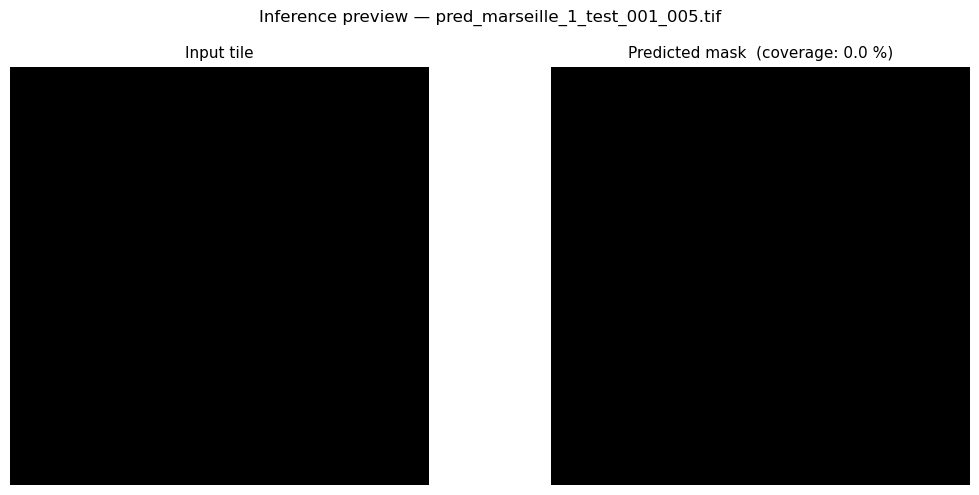


═══════════════════════════════════════════════════════
  Model    : U-Net + ResNet34
  Val IoU  : 0.6553
  Outputs  : /home/jovyan/predictions
  Preview  : predictions/inference_preview.png
  Format   : single-band uint8 GeoTIFF, LZW, values {0, 1}
═══════════════════════════════════════════════════════


In [35]:
from pathlib import Path
import rasterio
import rasterio.errors
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

NEW_TILES_DIR = Path("New Tiles")    
PRED_OUT_DIR  = Path("./predictions")         

# -----------------------------------------------------------------------------
# HELPER — read one tile safely with rasterio
# -----------------------------------------------------------------------------

def _safe_read_tile(tile_path: Path):
    """
    Open and read a .tif with rasterio.
    Returns (raw_array [C,H,W], profile) on success, or (None, None) on any
    read error (truncated strip, corrupt LZW stream, wrong size, etc.).
    """
    try:
        with rasterio.open(tile_path) as src:
            raw     = src.read()          # ← this is where TIFF errors explode
            profile = src.profile.copy()

        # Extra guard: skip tiles that are not exactly 512×512
        if raw.shape[1] != TARGET_SIZE or raw.shape[2] != TARGET_SIZE:
            print(f"  Warning:  Wrong size {raw.shape[1]}×{raw.shape[2]}, skipping: {tile_path.name}")
            return None, None

        return raw, profile

    # rasterio wraps GDAL errors as RasterioIOError; catch both the
    # high-level wrapper and the low-level CPLE exception just in case.
    except (rasterio.errors.RasterioIOError, Exception) as e:
        print(f"  Warning:  Skipping corrupted file [{type(e).__name__}]: {tile_path.name}")
        return None, None


# -----------------------------------------------------------------------------
# PREDICTION HELPERS
# -----------------------------------------------------------------------------

def _array_to_tensor(raw: np.ndarray, transform) -> torch.Tensor:
    """Convert a (C,H,W) uint8/float array to a normalised (1,3,H,W) tensor."""
    n = raw.shape[0]
    if n >= 3:
        raw = raw[:3]
    else:                                           # pad to 3 channels
        pad = np.zeros((3 - n, *raw.shape[1:]), dtype=raw.dtype)
        raw = np.concatenate([raw, pad], axis=0)

    img = np.moveaxis(raw, 0, -1).astype(np.float32)   # (H,W,3)
    if img.max() > 1.0:
        img = img / 255.0
    img = np.clip(img, 0.0, 1.0)

    dummy_mask = np.zeros(img.shape[:2], dtype=np.float32)
    aug        = transform(image=img, mask=dummy_mask)
    return aug["image"].unsqueeze(0)                    # (1,3,H,W)


@torch.no_grad()
def predict_single_tile(model, tile_path: Path, transform, device: str,
                        threshold: float = THRESHOLD):
    """
    Predict a binary mask for one .tif tile.
    Returns (mask_np [H,W] uint8 {0,1}, profile) or (None, None) if the
    file is corrupted / unreadable at any stage.
    """
    # -- 1. Read (all GDAL/TIFF errors caught here) ------------------------
    raw, profile = _safe_read_tile(tile_path)
    if raw is None:
        return None, None

    # -- 2. Pre-process & run model ----------------------------------------
    try:
        tensor = _array_to_tensor(raw, transform).to(device, non_blocking=True)

        with _get_autocast(device):
            logit = model(tensor)                       # (1,1,H,W)

        prob = torch.sigmoid(logit).squeeze().cpu().float().numpy()
        mask = (prob > threshold).astype(np.uint8)
        return mask, profile

    except Exception as e:
        print(f"  Warning:  Inference failed [{type(e).__name__}]: {tile_path.name}")
        return None, None


# -----------------------------------------------------------------------------
# MAIN PREDICTION LOOP
# -----------------------------------------------------------------------------

def predict_folder(model, transform, input_dir: Path, output_dir: Path,
                   device: str, threshold: float = THRESHOLD):
    """
    Run inference on every .tif in input_dir.
    Corrupted / unreadable tiles are logged and skipped automatically.
    Outputs: single-band uint8 LZW GeoTIFF, values {0, 1}.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    tiles = sorted(input_dir.glob("*.tif"))
    if not tiles:
        print(f"Warning:  No .tif files found in {input_dir}")
        return []

    print(f"Running inference on {len(tiles)} tiles  →  {output_dir}\n")

    saved    = []
    skipped  = []

    for tile_path in tqdm(tiles, desc="Predicting", unit="tile"):

        mask, profile = predict_single_tile(
            model, tile_path, transform, device, threshold
        )

        if mask is None:                        # corrupted — already logged above
            skipped.append(tile_path.name)
            continue

        # -- Write output mask --------------------------------------------
        profile.update(count=1, dtype=rasterio.uint8, compress="lzw", nodata=None)

        stem     = tile_path.stem              # original tile name without extension
        out_name = "pred_" + stem + ".tif"     # keep full original stem
        out_path = output_dir / out_name

        try:
            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(mask, 1)
            saved.append(out_path)
        except Exception as e:
            print(f"  Warning:  Could not write output [{type(e).__name__}]: {out_name}")
            skipped.append(tile_path.name)

    # -- Summary ----------------------------------------------------------
    print(f"\n{'-'*50}")
    print(f"  -  Saved   : {len(saved):>5} masks  →  {output_dir}")
    print(f"  Warning:  Skipped : {len(skipped):>5} corrupted / unreadable tiles")
    if skipped:
        print(f"\n  Skipped file list (first 20):")
        for name in skipped[:20]:
            print(f"    • {name}")
        if len(skipped) > 20:
            print(f"    … and {len(skipped) - 20} more")
    print(f"{'-'*50}\n")

    return saved


# -----------------------------------------------------------------------------
# RUN PREDICTION
# -----------------------------------------------------------------------------

predicted_files = predict_folder(
    best_model, BEST_TRANSFORM, NEW_TILES_DIR, PRED_OUT_DIR, DEVICE
)


# -----------------------------------------------------------------------------
# VISUAL CHECK — first successfully predicted tile
# -----------------------------------------------------------------------------

if predicted_files:
    sample_pred_path = predicted_files[0]

    # Try to find the matching input tile by stripping 'pred_' prefix
    input_stem = sample_pred_path.stem.replace("pred_", "")   # original stem
    sample_in  = NEW_TILES_DIR / f"{input_stem}.tif"

    has_input = sample_in.exists()
    fig, axes = plt.subplots(1, 2 if has_input else 1,
                             figsize=(11 if has_input else 5, 5))
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    if has_input:
        raw_in, _ = _safe_read_tile(sample_in)
        if raw_in is not None:
            rgb = np.moveaxis(raw_in[:3], 0, -1).astype(np.float32)
            if rgb.max() > 1.0:
                rgb = rgb / 255.0
            axes[0].imshow(rgb)
            axes[0].set_title("Input tile", fontsize=11)
        else:
            axes[0].set_title("Input tile (unreadable)", fontsize=11)
        axes[0].axis("off")
        ax_pred = axes[1]
    else:
        ax_pred = axes[0]

    with rasterio.open(sample_pred_path) as src:
        pred_vis = src.read(1)

    ax_pred.imshow(pred_vis, cmap="gray", vmin=0, vmax=1)
    coverage = pred_vis.mean() * 100
    ax_pred.set_title(f"Predicted mask  (coverage: {coverage:.1f} %)", fontsize=11)
    ax_pred.axis("off")

    plt.suptitle(f"Inference preview — {sample_pred_path.name}", fontsize=12)
    plt.tight_layout()
    plt.savefig(PRED_OUT_DIR / "inference_preview.png", dpi=150)
    plt.show()

    print(f"\n{'='*55}")
    print(f"  Model    : {BEST_NAME}")
    print(f"  Val IoU  : {RESULTS[BEST_NAME]['iou']:.4f}")
    print(f"  Outputs  : {PRED_OUT_DIR.resolve()}")
    print(f"  Preview  : {PRED_OUT_DIR / 'inference_preview.png'}")
    print(f"  Format   : single-band uint8 GeoTIFF, LZW, values {{0, 1}}")
    print(f"{'='*55}")
else:
    print("Warning:  No masks were produced — check NEW_TILES_DIR and the skipped-file list above.")